# 📊 WEEK 10 DAY 1: EXPLORATORY DATA ANALYSIS
**customer_churn.csv [file:312] - 500 Customers**

**Objective:** Understand data distribution, churn patterns, correlations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load dataset [file:312]
df = pd.read_csv('../data/customer_churn.csv')
print('Dataset shape:', df.shape)
print('\nChurn rate:', df['Churn'].mean())
df.head()

Dataset shape: (500, 9)

Churn rate: 0.106


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


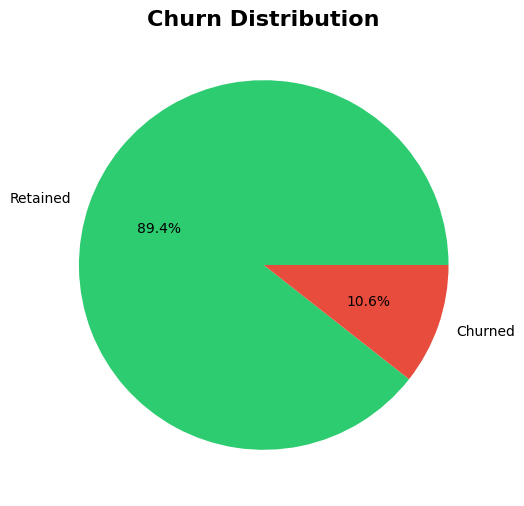

Churn rate: 10.6%


In [9]:
# 1. CHURN DISTRIBUTION [plots/01_churn_distribution.png]
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution', fontweight='bold', fontsize=16)
plt.savefig('../plots/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Churn rate: {churn_counts[1]/len(df)*100:.1f}%')

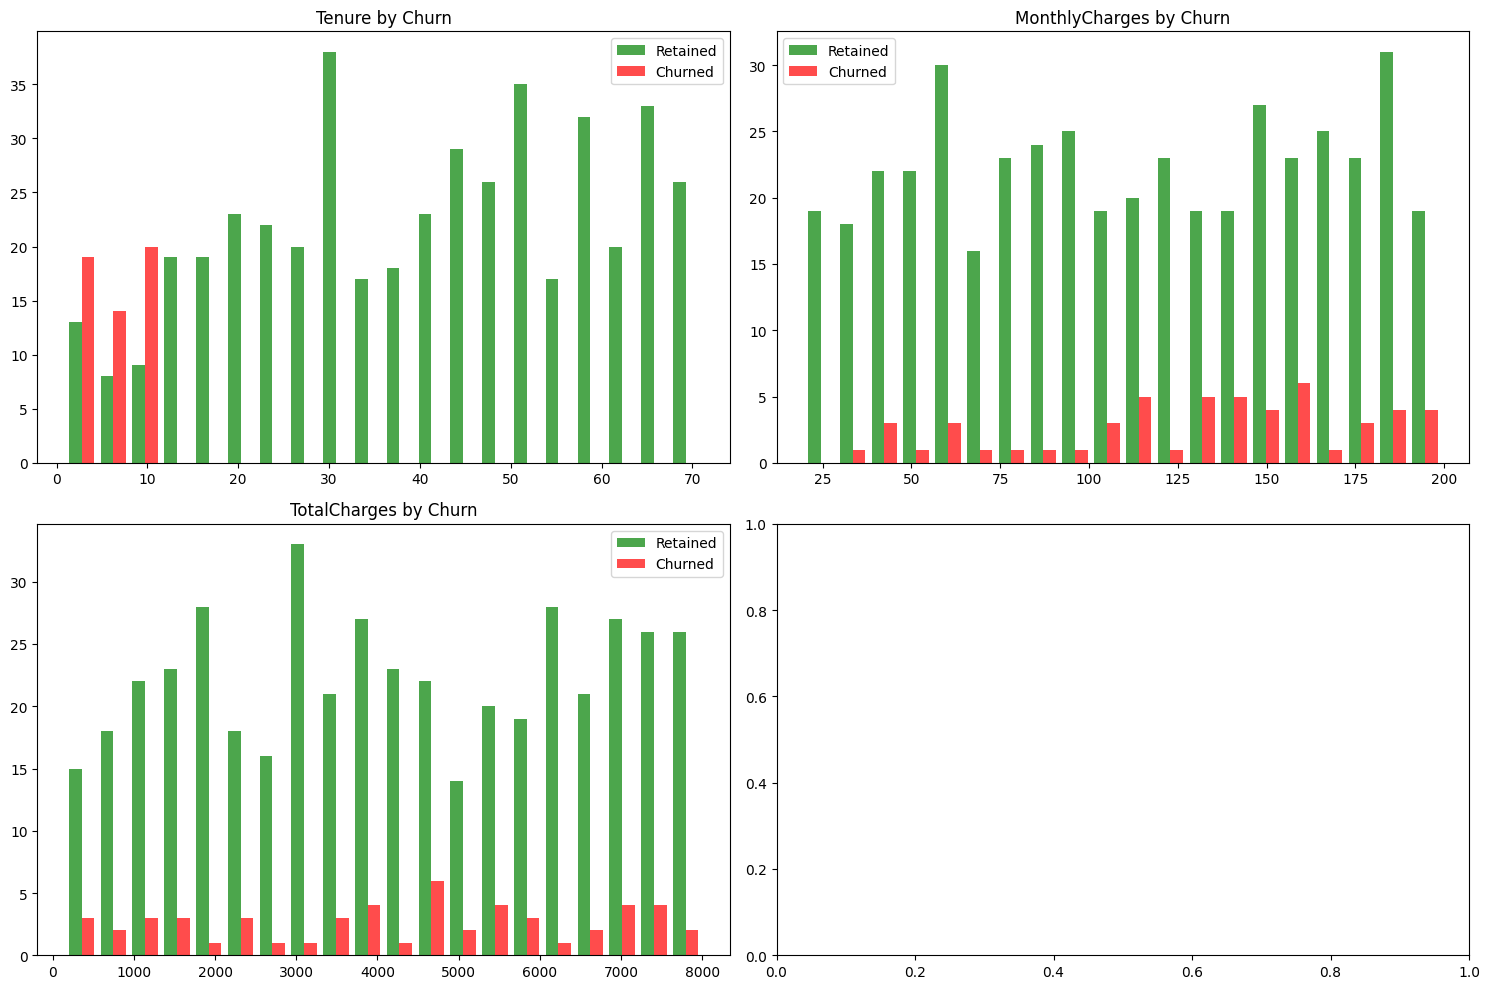

In [5]:
# 2. NUMERIC DISTRIBUTIONS
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, col in enumerate(['Tenure', 'MonthlyCharges', 'TotalCharges']):
    row, col_idx = divmod(i, 2)
    axes[row, col_idx].hist([df[df['Churn']==0][col], df[df['Churn']==1][col]], 
                           bins=20, alpha=0.7, label=['Retained', 'Churned'],
                           color=['green', 'red'])
    axes[row, col_idx].set_title(f'{col} by Churn')
    axes[row, col_idx].legend()

plt.tight_layout()
plt.savefig('../plots/02_numeric_distributions.png', dpi=300)
plt.show()

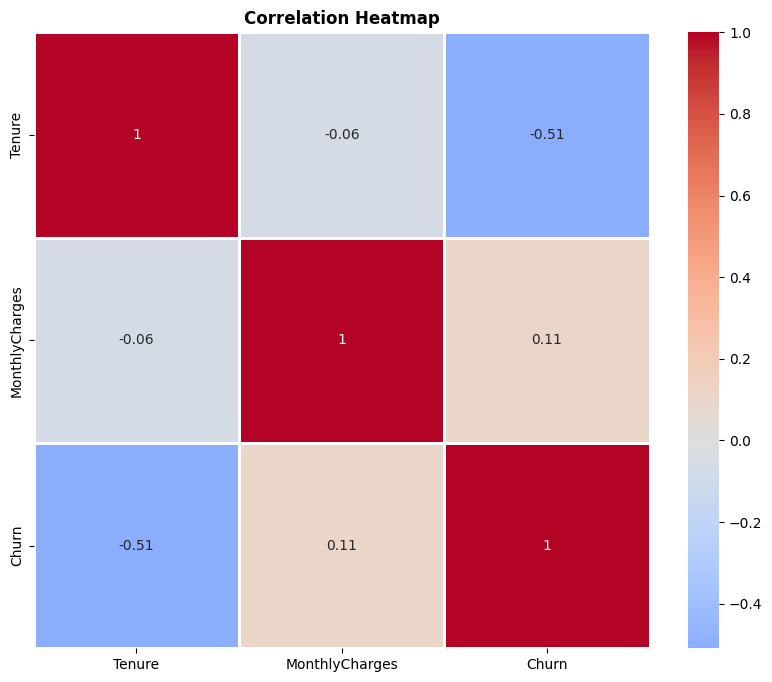

In [6]:
# 3. CORRELATION HEATMAP [plots/06_correlation_heatmap.png]
numeric_cols = ['Tenure', 'MonthlyCharges']
corr = df[numeric_cols + ['Churn']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Correlation Heatmap', fontweight='bold')
plt.savefig('../plots/06_correlation_heatmap.png', dpi=300)
plt.show()